In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision import models

from PIL import Image
import matplotlib.pyplot as plt
import json


In [ ]:
# loading the model
model = models.inception_v3(pretrained =  True)
model.eval() # as we need model only for the evaluation


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 177MB/s]


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
# transfrom the image as input to the image is (299,299,3)

def transform_image(image_path):
  transform = transforms.Compose([
      transforms.Resize((299,299)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  ])
  image = Image.open(image_path)
  return transform(image).unsqueeze(0) # add batch dimension

In [ ]:
# predicotion function

"""args
    image which is in numpy or tensor from
    model
    """
def prediction(image_tensor,model):
  with torch.no_grad(): # as beacuse we dont need any gradient
    output = model(image_tensor)
  probabilities = torch.nn.functional.softmax(output[0],dim = 0)
  return probabilities


In [ ]:
# downloading the label in the imagent >> as there are 1000 classes so we can't write them all so we gonna install and save in a new file
!wget https://raw.githubusercontent.com/pytorch/hub/refs/heads/master/imagenet_classes.txt

--2026-08-07 10:10:52--  https://raw.githubusercontent.com/pytorch/hub/refs/heads/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt.1’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2026-08-07 10:10:52 (60.9 MB/s) - ‘imagenet_classes.txt.1’ saved [10472/10472]



In [ ]:
with open("/content/imagenet_classes.txt") as f:
  labels = [line.strip() for line in f.readlines()]

In [ ]:
len(labels)

1000

In [ ]:
# if we made function for visualization
def visualize_prediction(imgae_path,predictions):
  image = Image.open(imgae_path)


  # set the title for the image
  top_5_prob,top_5_index = torch.topk(probabilities,5)
  top_5_label = [labels[i] for i in top_5_index]

  # show case the image
  plt.imshow(image)
  plt.title("\n".join(
            [f"{top_5_label[i]}: ({top_5_prob[i]:.3f})" for i in range(5)]
))
  plt.axis('off')



# torch.topk(probabilities, 5) is a PyTorch function used to find the top 5 highest probability values and their indices.

# It is commonly used after image classification models like VGG16, ResNet, InceptionV3 to get the top predictions.**bold text**

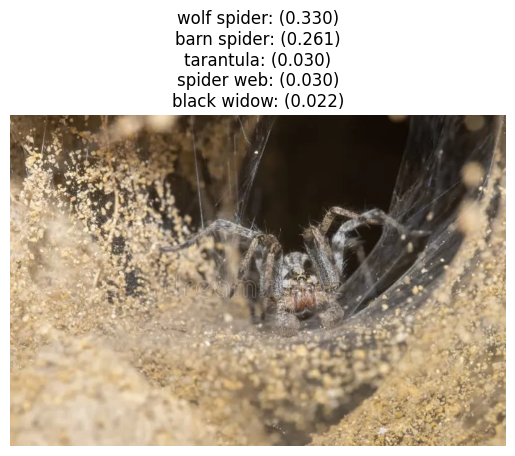

In [ ]:

img_path = "/content/wolf_spider.webp"
image_tensor_2 = transform_image(img_path)
predict = prediction(image_tensor_2,model)
visualize_prediction(img_path,predict)


# torch.topk(probabilities, 5) is a PyTorch function used to find the top 5 highest probability values and their indices.

# It is commonly used after image classification models like VGG16, ResNet, InceptionV3 to get the top predictions.

In [ ]:
top_5_prob,top_5_index = torch.topk(predict,5)
print(top_5_prob)
print(top_5_index)
top_5_label = [labels[i] for i in top_5_index]
print(top_5_label)

tensor([0.3304, 0.2614, 0.0302, 0.0295, 0.0220])
tensor([ 77,  73,  76, 815,  75])
['wolf spider', 'barn spider', 'tarantula', 'spider web', 'black widow']


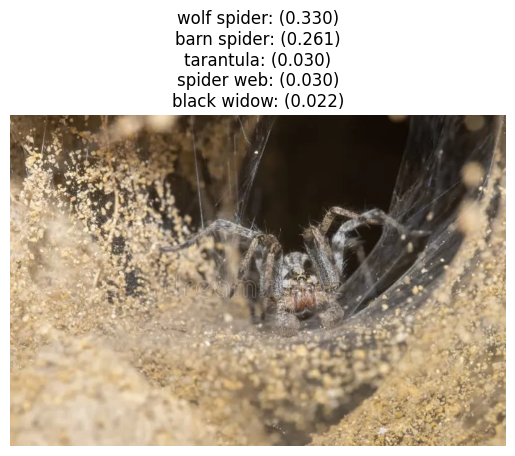

In [ ]:
image = Image.open('/content/wolf_spider.webp')
plt.imshow(image)
plt.title("\n".join(
            [f"{top_5_label[i]}: ({top_5_prob[i]:.3f})" for i in range(5)]
))
plt.axis('off')
plt.show()